# Ejemplo OSM con Python

Vamos a hacer un pequeño ejercicio con OpenStreetMap. Vamos a llamar al servicio de OpenStreetMap para pedirles que nos busque algunos elementos.

Primero tenemos que instalar el paquete de Python que nos permitirá explorar OSM

In [1]:
!pip install OSMPythonTools

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.7 MB/s eta 0:00:00
  Created wheel for OSMPythonTools: filename=OSMPythonTools-0.3.6-py3-none-any.whl size=32932 sha256=8c03cdd02e495608762a6ac0720e31f99c0419721f90c0b810ea2b02e6e266e8
  Stored in directory: /root/.cache/pip/wheels/02/41/ea/1ce9d03e7a92555934ab62bd27ff41b586a56683cdcab7d88e
Successfully built OSMPythonTools


Construimos la query, y se la envíamos al servidor de OSM.

Vamos a pedirle que nos busque "zonas verdes" (parques, jardines, bosques), dentro de una bounding box que encierra San Mateo de Gállego

In [2]:
from OSMPythonTools.overpass import Overpass

south, west, north, east = 41.82, -0.78, 41.84, -0.75

query = f"""
(
  nwr["leisure"="park"]({south},{west},{north},{east});
  nwr["leisure"="garden"]({south},{west},{north},{east});
  nwr["leisure"="nature_reserve"]({south},{west},{north},{east});
  nwr["leisure"="recreation_ground"]({south},{west},{north},{east});
  nwr["landuse"="grass"]({south},{west},{north},{east});
  nwr["landuse"="forest"]({south},{west},{north},{east});
  nwr["natural"="wood"]({south},{west},{north},{east});
  nwr["natural"="grassland"]({south},{west},{north},{east});
  nwr["natural"="heath"]({south},{west},{north},{east});
  nwr["natural"="scrub"]({south},{west},{north},{east});
);
out geom;
"""

overpass = Overpass()
result = overpass.query(query)

elements = result.elements()
print("Encontrados:", len(elements))

(
  nwr["leisure"="park"](41.82,-0.78,41.84,-0.75);
  nwr["leisure"="garden"](41.82,-0.78,41.84,-0.75);
  nwr["leisure"="nature_reserve"](41.82,-0.78,41.84,-0.75);
  nwr["leisure"="recreation_ground"](41.82,-0.78,41.84,-0.75);
  nwr["landuse"="grass"](41.82,-0.78,41.84,-0.75);
  nwr["landuse"="forest"](41.82,-0.78,41.84,-0.75);
  nwr["natural"="wood"](41.82,-0.78,41.84,-0.75);
  nwr["natural"="grassland"](41.82,-0.78,41.84,-0.75);
  nwr["natural"="heath"](41.82,-0.78,41.84,-0.75);
  nwr["natural"="scrub"](41.82,-0.78,41.84,-0.75);
);
out geom;



Encontrados: 25


Nota: Al terminar la query con "out geom" nos devolverá a geometría completa de los elemento (i.e. polígonos), si solo nos interesa el centro podemos terminar con "out center"

Esto es lo que nos devuelve. Es una lista de "cosas"


In [3]:
elements

Cada uno de los items de esta lista es un elemento que encajaría dentro de los parámetros de búsqueda que hemos establecido. Desgraciadamente, así no vemos mucho mas, pero cada uno de estos elementos tienen dentro más información.

Por ejemplo, vamos a pedirle que nos muestre el id del elemento, y los "tags" asociados.

In [4]:
for element in elements:
    print(element.id(), element.tags())

49359985 {'landuse': 'forest'}
373434541 {'leisure': 'park'}
373508730 {'leisure': 'park'}
844372262 {'natural': 'wood'}
848662508 {'landuse': 'grass'}
848662509 {'landuse': 'grass'}
848662511 {'landuse': 'grass'}
848662526 {'landuse': 'grass'}
848662527 {'landuse': 'grass'}
848662546 {'landuse': 'grass'}
848662551 {'access': 'no', 'leisure': 'garden'}
848662552 {'access': 'no', 'leisure': 'garden'}
848662553 {'access': 'no', 'leisure': 'garden'}
848662577 {'landuse': 'grass'}
848662578 {'landuse': 'grass'}
848662579 {'landuse': 'grass'}
848662580 {'landuse': 'grass'}
862099533 {'landuse': 'grass'}
862099537 {'landuse': 'grass'}
862099538 {'landuse': 'grass'}
862099560 {'natural': 'heath'}
1105722030 {'landuse': 'forest', 'leaf_cycle': 'evergreen', 'leaf_type': 'needleleaved'}
1105722036 {'landuse': 'forest'}
1444538973 {'leisure': 'nature_reserve', 'name': 'LIC Bajo Gállego', 'operator': 'Gobierno de Aragón', 'operator:type': 'government'}
11779847 {'landuse': 'grass', 'type': 'multip

Podemos organizar esta información en un dataframe

In [5]:
import pandas as pd
from shapely.geometry import Point, shape

rows_simple = []

for element in elements:
    tags = element.tags() or {}
    osm_type = element.type()
    osm_id = element.id()

    lat = None
    lon = None

    if osm_type == 'node':
        lat = element.lat()
        lon = element.lon()
    else: # For 'way' or 'relation'
        geojson_geom = element.geometry()
        if geojson_geom:
            try:
                s_geom = shape(geojson_geom)
                # Ensure the geometry is valid and has a centroid
                if s_geom.is_valid and not s_geom.is_empty:
                    lat = s_geom.centroid.y
                    lon = s_geom.centroid.x
            except Exception:
                # Fallback to center coordinates if shapely conversion or centroid fails
                lat = element.centerLat()
                lon = element.centerLon()
        else:
            # Fallback to center coordinates if element.geometry() returns None
            lat = element.centerLat()
            lon = element.centerLon()

    # Only append to dataframe if valid latitude and longitude are found
    if lat is not None and lon is not None:
        rows_simple.append(
            {
                "osm_type": osm_type,
                "osm_id": osm_id,
                "name": tags.get("name"),
                "leisure": tags.get("leisure"),
                "landuse": tags.get("landuse"),
                "natural": tags.get("natural"),
                "latitude": lat,
                "longitude": lon,
                "tags": tags,
            }
        )

df_simple = pd.DataFrame(rows_simple)
display(df_simple.head())

,osm_type,osm_id,name,leisure,landuse,natural,latitude,longitude,tags
0,way,49359985,None,None,forest,None,41.843173,-0.776609,{'landuse': 'forest'}
1,way,373434541,None,park,None,None,41.829102,-0.770775,{'leisure': 'park'}
2,way,373508730,None,park,None,None,41.830747,-0.765377,{'leisure': 'park'}
3,way,844372262,None,None,None,wood,41.831782,-0.769300,{'natural': 'wood'}
4,way,848662508,None,None,grass,None,41.835509,-0.763935,{'landuse': 'grass'}


Existe un objeto particular para este tipo de datos llamado "geodataframe" (de la librería geopandas)


In [7]:
import geopandas
from shapely.geometry import Point, LineString, Polygon, shape

geometries = []
data = []

for element in elements:
    tags = element.tags() or {}
    osm_type = element.type()
    osm_id = element.id()
    name = tags.get('name')
    leisure = tags.get('leisure')
    landuse = tags.get('landuse')
    natural_tag = tags.get('natural')

    geometry = None

    if osm_type == 'node':
        lat = element.lat()
        lon = element.lon()
        if lat is not None and lon is not None:
            geometry = Point(lon, lat)
    elif osm_type == 'way' or osm_type == 'relation':
        # For ways and relations, 'out geom;' in the query provides full geometry
        # which can be accessed via element.geometry()
        geojson_geom = element.geometry()
        if geojson_geom:
            try:
                geometry = shape(geojson_geom)
            except Exception as e:
                print(f"Warning: Could not convert element {osm_id} (type: {osm_type}) geometry from GeoJSON: {e}. Skipping geometry creation.")
                geometry = None
        else:
            # Fallback to center point if no full geometry was obtained
            lat = element.centerLat()
            lon = element.centerLon()
            if lat is not None and lon is not None:
                geometry = Point(lon, lat)
            else:
                print(f"Warning: No valid geometry or coordinates found for element {osm_id} (type: {osm_type}). Skipping geometry creation.")
                geometry = None

    if geometry: # Only append if we successfully created a geometry object
        data.append({
            "osm_type": osm_type,
            "osm_id": osm_id,
            "name": name,
            "leisure": leisure,
            "landuse": landuse,
            "natural": natural_tag,
            "tags": tags
        })
        geometries.append(geometry)

# Create a GeoDataFrame
gdf = geopandas.GeoDataFrame(data, geometry=geometries, crs="EPSG:4326")

display(gdf.head())

,osm_type,osm_id,name,leisure,landuse,natural,tags,geometry
0,way,49359985,None,None,forest,None,{'landuse': 'forest'},"POLYGON ((-0.77872 41.84757, -0.77657 41.84642..."
1,way,373434541,None,park,None,None,{'leisure': 'park'},"POLYGON ((-0.77123 41.82906, -0.77105 41.82919..."
2,way,373508730,None,park,None,None,{'leisure': 'park'},"POLYGON ((-0.76503 41.83081, -0.76556 41.83097..."
3,way,844372262,None,None,None,wood,{'natural': 'wood'},"POLYGON ((-0.76934 41.83206, -0.76942 41.83195..."
4,way,848662508,None,None,grass,None,{'landuse': 'grass'},"POLYGON ((-0.76412 41.83556, -0.76378 41.83555..."


Los geodataframe tienen una columna llamada "geometry", que contiene la geometria del objeto.

Y podemos pintar estos elementos

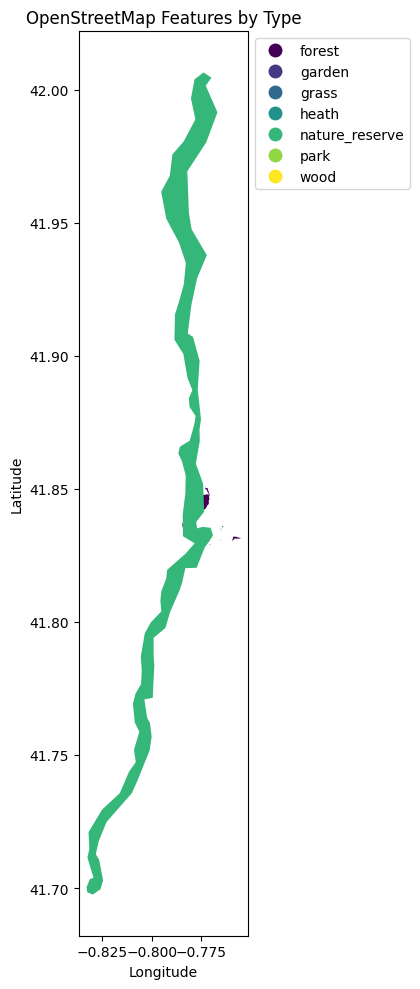

In [8]:
import matplotlib.pyplot as plt

# Create a combined 'feature_type' column for coloring
gdf['feature_type'] = gdf['leisure'].fillna(gdf['landuse']).fillna(gdf['natural']).fillna('other')

# Set up the plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the GeoDataFrame, using 'feature_type' for color
gdf.plot(
    column='feature_type',
    ax=ax,
    legend=True,
    legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    cmap='viridis',
    markersize=50
)

# Add title and labels
ax.set_title('OpenStreetMap Features by Type')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Adjust layout to prevent legend overlap
plt.tight_layout()
plt.show()

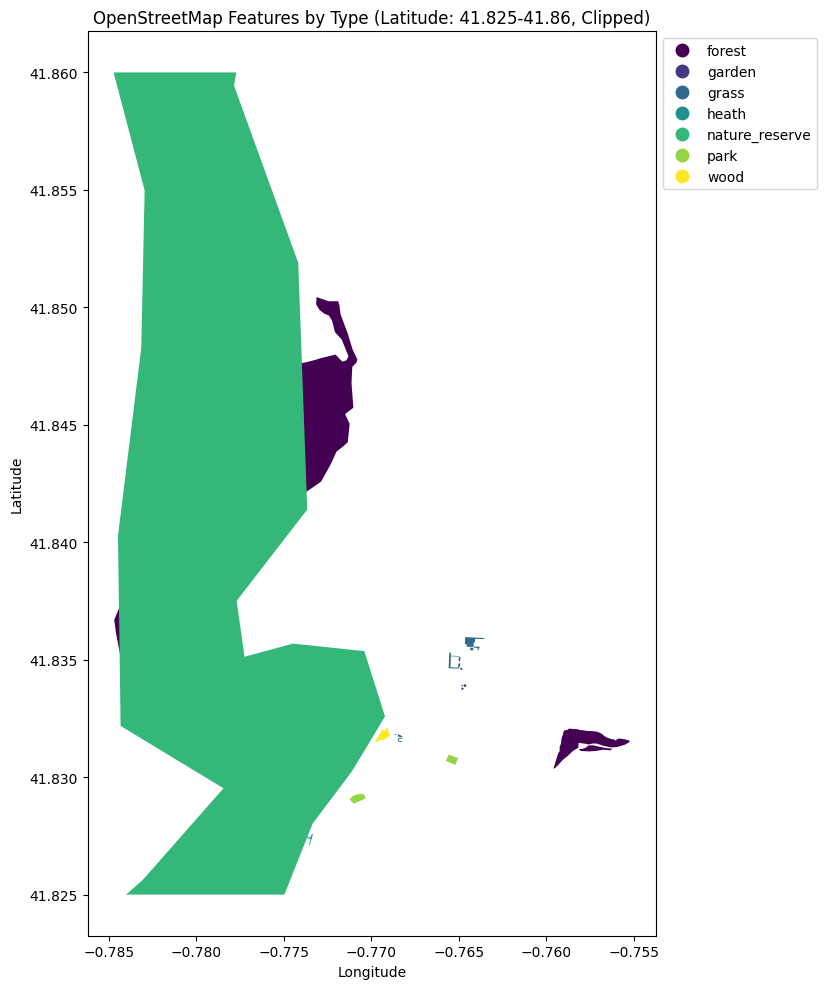

In [9]:
import geopandas
from shapely.geometry import box
import matplotlib.pyplot as plt

# Define the latitude range as requested
min_lat = 41.825
max_lat = 41.86

# Get the overall longitude range from the original GeoDataFrame
min_lon, _, max_lon, _ = gdf.total_bounds

# Create a clipping polygon (bounding box) using the specified latitude range
# and the full longitude range of the data.
clipping_box = box(min_lon, min_lat, max_lon, max_lat)

# Clip the GeoDataFrame using the clipping box
gdf_clipped = gdf.clip(clipping_box)

# Set up the plot for the clipped data
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot the clipped GeoDataFrame, using 'feature_type' for color
gdf_clipped.plot(
    column='feature_type',
    ax=ax,
    legend=True,
    legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1)},
    cmap='viridis',
    markersize=50
)

# Add title and labels
ax.set_title(f'OpenStreetMap Features by Type (Latitude: {min_lat}-{max_lat}, Clipped)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# Adjust layout to prevent legend overlap
plt.tight_layout()
plt.show()

Podemos añadirle un poco más de contexto...

In [10]:
import folium

# Get the centroid of the clipped GeoDataFrame to center the map
# Handle potential empty gdf_clipped case
if not gdf_clipped.empty:
    center_lat = gdf_clipped.centroid.y.mean()
    center_lon = gdf_clipped.centroid.x.mean()
else:
    # Fallback to the original bounding box center if clipped data is empty
    center_lat = (min_lat + max_lat) / 2
    center_lon = (min_lon + max_lon) / 2

# Create a Folium map centered on the clipped data
m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

# Define a color mapping for the 'feature_type' for consistency
# You might want to use a more robust color palette if there are many unique types
unique_feature_types = gdf_clipped['feature_type'].unique()
colors = plt.cm.get_cmap('viridis', len(unique_feature_types))
color_map = {ftype: f'#{int(colors(i)[0]*255):02x}{int(colors(i)[1]*255):02x}{int(colors(i)[2]*255):02x}' for i, ftype in enumerate(unique_feature_types)}

# Add each feature from the clipped GeoDataFrame to the map
for _, row in gdf_clipped.iterrows():
    feature_color = color_map.get(row['feature_type'], '#808080') # Default to grey if not in map
    if row.geometry.geom_type == 'Point':
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=5,
            color=feature_color,
            fill=True,
            fill_color=feature_color,
            tooltip=f"Type: {row['feature_type']}, Name: {row['name'] or 'N/A'}"
        ).add_to(m)
    elif row.geometry.geom_type in ['Polygon', 'MultiPolygon']:
        folium.GeoJson(
            row.geometry.__geo_interface__,
            style_function=lambda x, color=feature_color: {
                'fillColor': color,
                'color': color,
                'weight': 1,
                'fillOpacity': 0.7
            },
            tooltip=f"Type: {row['feature_type']}, Name: {row['name'] or 'N/A'}"
        ).add_to(m)
    elif row.geometry.geom_type in ['LineString', 'MultiLineString']:
        folium.GeoJson(
            row.geometry.__geo_interface__,
            style_function=lambda x, color=feature_color: {
                'color': color,
                'weight': 3,
                'opacity': 0.7
            },
            tooltip=f"Type: {row['feature_type']}, Name: {row['name'] or 'N/A'}"
        ).add_to(m)

# Display the map
m

/tmp/ipykernel_1429/2369733582.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = gdf_clipped.centroid.y.mean()
/tmp/ipykernel_1429/2369733582.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = gdf_clipped.centroid.x.mean()
/tmp/ipykernel_1429/2369733582.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', len(unique_feature_types))
